### Album prediction


In [1]:
from pathlib import Path
import random
import pickle
import numpy as np
import pandas as pd
from scipy import sparse
import os
import psycopg
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MultiLabelBinarizer
from dotenv import load_dotenv
from sklearn.impute import SimpleImputer
from sklearn.neighbors import NearestNeighbors

In [2]:
%time

load_dotenv(dotenv_path=Path("../.env"))

conn = psycopg.connect(
    dbname=os.getenv("DATABASE"),
    user=os.getenv("DB_USERNAME"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("POSTGRES"),
    port=5432
)

query = """
WITH all_tag_links AS (
    SELECT
        r.release_group,
        rt.tag AS tag_id
    FROM release r
    JOIN release_tag rt
        ON rt.release = r.id

    UNION ALL

    SELECT
        rgt.release_group,
        rgt.tag AS tag_id
    FROM release_group_tag rgt
),
tag_classified AS (
    SELECT
        atl.release_group,
        atl.tag_id,
        g.id AS genre_id
    FROM all_tag_links atl
    JOIN tag t
        ON t.id = atl.tag_id
    LEFT JOIN genre g
        ON g.name = t.name
),
tag_counts AS (
    SELECT
        release_group,
        tag_id,
        COUNT(*) AS tag_count
    FROM tag_classified
    WHERE genre_id IS NULL
    GROUP BY release_group, tag_id
),
genre_counts AS (
    SELECT
        release_group,
        genre_id,
        COUNT(*) AS genre_count
    FROM tag_classified
    WHERE genre_id IS NOT NULL
    GROUP BY release_group, genre_id
),
tag_buckets AS (
    SELECT
        release_group,
        array_agg(DISTINCT tag_id ORDER BY tag_id) AS tag_ids
    FROM tag_counts
    WHERE tag_count > 1
    GROUP BY release_group
),
genre_buckets AS (
    SELECT
        release_group,
        array_agg(DISTINCT genre_id ORDER BY genre_id) AS genre_ids
    FROM genre_counts
    WHERE genre_count > 0
    GROUP BY release_group
),
release_meta AS (
    SELECT
        r.release_group,
        mode() WITHIN GROUP (ORDER BY r.status) AS status,
        mode() WITHIN GROUP (ORDER BY r.language) AS language,
        mode() WITHIN GROUP (ORDER BY r.script) AS script
    FROM release r
    GROUP BY r.release_group
),
secondary_types AS (
    SELECT
        release_group,
        array_agg(DISTINCT secondary_type ORDER BY secondary_type) AS secondary_type_ids
    FROM release_group_secondary_type_join
    GROUP BY release_group
)
SELECT
    rg.id,
    rg.type,
    rgm.first_release_date_year AS year,
    COALESCE(tb.tag_ids, ARRAY[]::integer[]) AS tag_ids,
    COALESCE(gb.genre_ids, ARRAY[]::integer[]) AS genre_ids,
    rm.status,
    rm.language,
    rm.script,
    COALESCE(st.secondary_type_ids, ARRAY[]::integer[]) AS secondary_type_ids
FROM release_group rg
LEFT JOIN release_group_meta rgm
    ON rgm.id = rg.id
LEFT JOIN tag_buckets tb
    ON tb.release_group = rg.id
LEFT JOIN genre_buckets gb
    ON gb.release_group = rg.id
LEFT JOIN release_meta rm
    ON rm.release_group = rg.id
LEFT JOIN secondary_types st
    ON st.release_group = rg.id
"""

data_sql = pd.read_sql_query(query, conn)
conn.close()

data_sql = data_sql.astype({
    "id": "int64",
    "type": "Int32",
    "year": "Int32",
    "status": "Int32",
    "language": "Int32",
    "script": "Int32"
})

print("Connection successful")
print(data_sql.shape)
display(data_sql.head())

CPU times: user 2 μs, sys: 0 ns, total: 2 μs
Wall time: 3.34 μs


/tmp/ipykernel_179555/1980450347.py:113: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data_sql = pd.read_sql_query(query, conn)


Connection successful
(4325766, 9)


,id,type,year,tag_ids,genre_ids,status,language,script,secondary_type_ids
0,2,1,2000,[],[],1,120,28,[1]
1,4,1,1991,[],"[2, 8, 14, 95, 115, 119, 132, 134, 158, 199, 2...",1,120,28,[]
2,11,1,1996,[],"[222, 338, 382, 1574]",1,120,28,[]
3,12,1,2000,[],"[14, 18, 42, 86, 90, 150, 346]",1,120,28,[]
4,13,1,1995,[],"[222, 382, 635]",1,120,28,[]


### Checking types

In [3]:
data_pre_group = data_sql.copy()

In [4]:
data_pre_group.dtypes

id                     int64
type                   Int32
year                   Int32
tag_ids               object
genre_ids             object
status                 Int32
language               Int32
script                 Int32
secondary_type_ids    object
dtype: object

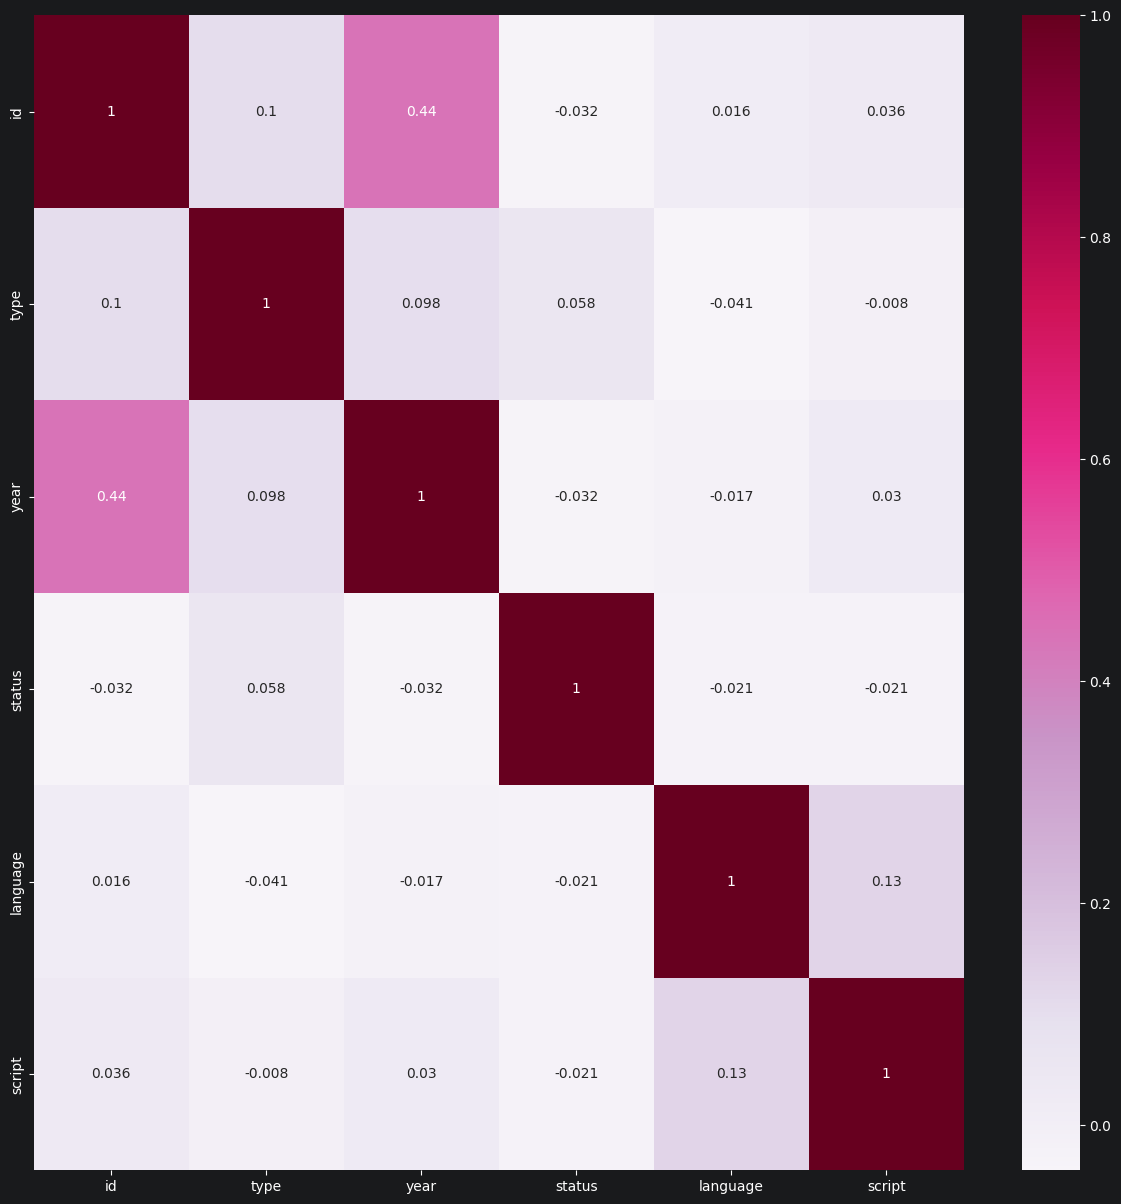

In [5]:
plt.figure(figsize = (15,15))
sns.heatmap(data_pre_group.corr(numeric_only = True),
annot=True,
cmap="PuRd");

### Number of duplicates

In [6]:
data_pre_group_hashable = data_pre_group.map(
    lambda x: tuple(x) if isinstance(x, list) else x
)
number_of_duplicated_rows = data_pre_group_hashable.duplicated().sum()
number_of_duplicated_rows

np.int64(0)

### Checking null values repartition

In [7]:
# data_pre_group = data_pre_group.dropna(subset=["genre_id"])
# data_pre_group
data_pre_group.isna().sum()

id                         0
type                   98469
year                  198221
tag_ids                    0
genre_ids                  0
status                232487
language              637598
script                642883
secondary_type_ids         0
dtype: int64

### Droping data without type

In [8]:
data_null_type = data_pre_group[data_pre_group["type"].isna()].copy()
release_groups = data_null_type["id"].unique().tolist()

In [9]:
%time

conn = psycopg.connect(
    dbname=os.getenv("DATABASE"),
    user=os.getenv("DB_USERNAME"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("POSTGRES"),
    port=5432
)

sec_query = """
WITH release_groups_filter AS (
    SELECT rid
    FROM unnest(%s::int[]) AS t(rid)
),
ranked_releases AS (
    SELECT
        r.release_group,
        r.id AS release_id,
        row_number() OVER (
            PARTITION BY r.release_group
            ORDER BY
                CASE
                    WHEN lower(r.name) LIKE '%%super deluxe%%' THEN 1
                    WHEN lower(r.name) LIKE '%%deluxe%%' THEN 1
                    WHEN lower(r.name) LIKE '%%expanded%%' THEN 1
                    WHEN lower(r.name) LIKE '%%anniversary%%' THEN 1
                    WHEN lower(r.name) LIKE '%%bonus%%' THEN 1
                    WHEN lower(r.name) LIKE '%%collector%%' THEN 1
                    ELSE 0
                END,
                COALESCE(rc.date_year, ruc.date_year) NULLS LAST,
                COALESCE(rc.date_month, ruc.date_month) NULLS LAST,
                COALESCE(rc.date_day, ruc.date_day) NULLS LAST,
                r.id
        ) AS rn
    FROM release_groups_filter rgf
    JOIN release r
        ON r.release_group = rgf.rid
    LEFT JOIN release_country rc
        ON rc.release = r.id
    LEFT JOIN release_unknown_country ruc
        ON ruc.release = r.id
        AND rc.release IS NULL
),
chosen_release AS (
    SELECT release_group, release_id
    FROM ranked_releases
    WHERE rn = 1
),
release_track_meta AS (
    SELECT
        cr.release_group,
        COUNT(t.id) AS track_numbers,
        SUM(t.length) AS album_length_ms
    FROM chosen_release cr
    JOIN medium m
        ON m.release = cr.release_id
    JOIN track t
        ON t.medium = m.id
    GROUP BY cr.release_group
)
SELECT
    release_group AS id,
    track_numbers,
    album_length_ms
FROM release_track_meta
"""

db_data = pd.read_sql_query(sec_query, conn, params=(release_groups,))
conn.close()

db_data.shape

CPU times: user 2 μs, sys: 0 ns, total: 2 μs
Wall time: 5.96 μs


/tmp/ipykernel_179555/1613785732.py:70: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  db_data = pd.read_sql_query(sec_query, conn, params=(release_groups,))


(97810, 3)

### Defining release_group type from track number or release_group length

In [10]:
# Merge track_numbers and album_length_ms into the null-type subset
data_null_type = data_null_type.merge(
    db_data,
    on="id",
    how="left"
)

# Ensure dtypes for calculations
data_null_type["track_numbers"] = data_null_type["track_numbers"].astype("Int32")
data_null_type["album_length_ms"] = data_null_type["album_length_ms"].astype("Int64")

# Define thresholds
TRACKS_FOR_ALBUM = 8
LENGTH_MS_FOR_ALBUM = 30 * 60 * 1000  # 30 minutes
LENGTH_MS_FOR_SINGLE = 7 * 60 * 1000  # 7 minutes

# Compute new type only for null-type rows
def classify_type(row):
    tn = row["track_numbers"]
    lm = row["album_length_ms"]

    if tn is None or lm is None or tn is pd.NA or lm is pd.NA:
        return pd.NA

    tn = int(tn)
    lm = int(lm)

    if tn > TRACKS_FOR_ALBUM or lm > LENGTH_MS_FOR_ALBUM:
        return 1
    elif tn == 1 and lm < LENGTH_MS_FOR_SINGLE:
        return 2
    else:
        return 3

data_null_type["type"] = data_null_type.apply(classify_type, axis=1)

print("Null-type release groups updated:")
display(data_null_type[["id", "type", "track_numbers", "album_length_ms"]].head())

# Now update the original `data` dataframe:
# - Keep existing type for rows where type is not null
# - Use computed type for rows where type was null
computed_type_map = data_null_type.set_index("id")["type"]

data = data_pre_group.copy()

# Only update rows where type is null
data["type"] = data["type"].fillna(
    data["id"].map(computed_type_map)
).astype("Int32")

Null-type release groups updated:


,id,type,track_numbers,album_length_ms
0,144,1,15,4515000
1,473,1,15,2983000
2,474,1,25,129000
3,580,<NA>,6,<NA>
4,583,<NA>,2,<NA>


In [11]:
print("Updated full data:")
data.isna().sum()

Updated full data:


id                         0
type                   22074
year                  198221
tag_ids                    0
genre_ids                  0
status                232487
language              637598
script                642883
secondary_type_ids         0
dtype: int64

In [12]:
empty_tag_ids_count = (data["tag_ids"].apply(lambda x: len(x)) == 0).sum() if "tag_ids" in data.columns else 0
empty_genre_ids_count = (data["genre_ids"].apply(lambda x: len(x)) == 0).sum() if "genre_ids" in data.columns else 0

print(f"Empty tag_ids: {empty_tag_ids_count}")
print(f"Empty genre_ids: {empty_genre_ids_count}")

Empty tag_ids: 4272597
Empty genre_ids: 2564672


In [13]:
empty_genre_rg_ids = (
    data
    .loc[data["genre_ids"].apply(lambda x: len(x) == 0), "id"]
    .unique()
)

print(f"Total release groups with empty genre list: {len(empty_genre_rg_ids)}")

if len(empty_genre_rg_ids) == 0:
    print("No release groups with empty genre list.")
    df_result = pd.DataFrame()
else:
    empty_genre_rg_ids = empty_genre_rg_ids.astype(int)

    conn = psycopg.connect(
        dbname=os.getenv("DATABASE"),
        user=os.getenv("DB_USERNAME"),
        password=os.getenv("DB_PASSWORD"),
        host=os.getenv("POSTGRES"),
        port=5432
    )

    with conn.cursor() as cur:
        # Create temp table
        cur.execute("""
            CREATE TEMP TABLE IF NOT EXISTS tmp_empty_genre_rg (
                release_group_id INT PRIMARY KEY
            );
        """)

        cur.execute("TRUNCATE TABLE tmp_empty_genre_rg;")

        insert_query = "INSERT INTO tmp_empty_genre_rg (release_group_id) VALUES (%s);"
        cur.executemany(insert_query, ((rg_id,) for rg_id in empty_genre_rg_ids))
        conn.commit()

        # Full query with aggregation
        query = """
        WITH artist_tag_links AS (
            SELECT
                r.release_group,
                rt.tag AS tag_id
            FROM tmp_empty_genre_rg t
            JOIN release r
                ON r.release_group = t.release_group_id
            JOIN artist_credit ac
                ON ac.id = r.artist_credit
            JOIN artist_credit_name acn
                ON acn.artist_credit = ac.id
            JOIN artist_tag rt
                ON rt.artist = acn.artist
        ),
        tag_counts AS (
            SELECT
                release_group,
                tag_id,
                COUNT(*) AS tag_count
            FROM artist_tag_links
            GROUP BY release_group, tag_id
        ),
        tag_with_genre AS (
            SELECT
                atl.release_group,
                atl.tag_id,
                g.id AS genre_id
            FROM artist_tag_links atl
            JOIN tag t
                ON t.id = atl.tag_id
            LEFT JOIN genre g
                ON g.name = t.name
        ),
        genre_counts AS (
            SELECT
                release_group,
                genre_id,
                COUNT(*) AS genre_count
            FROM tag_with_genre
            WHERE genre_id IS NOT NULL
            GROUP BY release_group, genre_id
        ),
        tag_buckets AS (
            SELECT
                release_group,
                array_agg(DISTINCT tag_id ORDER BY tag_id) AS tag_ids
            FROM tag_counts
            WHERE tag_count > 1
            GROUP BY release_group
        ),
        genre_buckets AS (
            SELECT
                release_group,
                array_agg(DISTINCT genre_id ORDER BY genre_id) AS genre_ids
            FROM genre_counts
            WHERE genre_count > 0
            GROUP BY release_group
        )
        SELECT
            t.release_group_id AS id,
            COALESCE(tb.tag_ids, ARRAY[]::integer[]) AS tag_ids,
            COALESCE(gb.genre_ids, ARRAY[]::integer[]) AS genre_ids
        FROM tmp_empty_genre_rg t
        LEFT JOIN tag_buckets tb
            ON tb.release_group = t.release_group_id
        LEFT JOIN genre_buckets gb
            ON gb.release_group = t.release_group_id;
        """

        df_result = pd.read_sql_query(query, conn)

        print(f"Rows returned: {len(df_result)}")
        display(df_result.head())

    conn.close()

Total release groups with empty genre list: 2564672


/tmp/ipykernel_179555/3185860756.py:108: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_result = pd.read_sql_query(query, conn)


Rows returned: 2564672


,id,tag_ids,genre_ids
0,3999,[],"[15, 41, 42, 43, 56, 65, 75, 86, 90, 126, 132,..."
1,6091,[],"[300, 330]"
2,6565,[],"[15, 41, 42, 43, 56, 65, 75, 86, 90, 126, 132,..."
3,6601,[],"[15, 41, 42, 43, 56, 65, 75, 86, 90, 126, 132,..."
4,6805,[],[]


In [14]:
# Now update the original `data` dataframe:
# - Keep existing tag_ids and genre_ids where they are not empty
# - Use computed values where they are empty lists

computed_genre_map = df_result.set_index("id")["genre_ids"]
computed_tag_map = df_result.set_index("id")["tag_ids"]

data_test = data.copy()

def is_empty_list(x):
    return isinstance(x, list) and len(x) == 0

# Update tag_ids
mask_empty_tag = data_test["tag_ids"].apply(is_empty_list)
mapped_tag = data_test.loc[mask_empty_tag, "id"].map(computed_tag_map)
# Fill NaN with empty list
mapped_tag = mapped_tag.apply(lambda x: x if isinstance(x, list) else [])
data_test.loc[mask_empty_tag, "tag_ids"] = mapped_tag

# Update genre_ids
mask_empty_genre = data_test["genre_ids"].apply(is_empty_list)
mapped_genre = data_test.loc[mask_empty_genre, "id"].map(computed_genre_map)
# Fill NaN with empty list
mapped_genre = mapped_genre.apply(lambda x: x if isinstance(x, list) else [])
data_test.loc[mask_empty_genre, "genre_ids"] = mapped_genre

new_empty_tag_ids_count = (
    data_test["tag_ids"].apply(is_empty_list)
).sum() if "tag_ids" in data_test.columns else 0

new_empty_genre_ids_count = (
    data_test["genre_ids"].apply(is_empty_list)
).sum() if "genre_ids" in data_test.columns else 0

print(f"Empty tag_ids: {new_empty_tag_ids_count}")
print(f"Empty genre_ids: {new_empty_genre_ids_count} ({round(new_empty_genre_ids_count / data_test.shape[0] * 100)}%)")
print(f"\nSample of updated tag_ids:")
display(data_test[["id", "tag_ids", "genre_ids"]].head(10))

Empty tag_ids: 4070585
Empty genre_ids: 1474670 (34%)

Sample of updated tag_ids:


,id,tag_ids,genre_ids
0,2,[],"[15, 41, 42, 43, 56, 65, 75, 86, 90, 126, 132,..."
1,4,[],"[2, 8, 14, 95, 115, 119, 132, 134, 158, 199, 2..."
2,11,[],"[222, 338, 382, 1574]"
3,12,[],"[14, 18, 42, 86, 90, 150, 346]"
4,13,[],"[222, 382, 635]"
5,24,[],"[15, 41, 42, 43, 56, 65, 75, 86, 90, 126, 132,..."
6,28,[],"[48, 131, 132, 212, 281, 403]"
7,30,[],"[14, 173, 209, 310, 315, 330, 331, 346, 952]"
8,37,[507],"[85, 222, 276, 805, 1701]"
9,50,[],"[14, 188, 346]"


### train Pipeline

In [15]:
class ListToSparseTransformer(BaseEstimator, TransformerMixin):
    """
    Transformer that:
      - imputes scalar columns (type, status, language, script, year)
      - multi-label binarizes list columns (tag_ids, genre_ids, secondary_type_ids)
      - returns a single sparse matrix
    """

    def __init__(self, categorical_cols, numeric_mean_cols, list_cols):
        self.categorical_cols = categorical_cols
        self.numeric_mean_cols = numeric_mean_cols
        self.list_cols = list_cols

        self.imputers = {}
        self.mlbs = {}

    def fit(self, X, y=None):
        # Fit imputers
        if self.categorical_cols:
            self.imputers["categorical"] = SimpleImputer(strategy="most_frequent")
            self.imputers["categorical"].fit(X[self.categorical_cols])

        if self.numeric_mean_cols:
            self.imputers["numeric"] = SimpleImputer(strategy="mean")
            self.imputers["numeric"].fit(X[self.numeric_mean_cols])

        # Fit MultiLabelBinarizers
        for col in self.list_cols:
            self.mlbs[col] = MultiLabelBinarizer(sparse_output=True)
            X_list = X[col].apply(self._ensure_list)
            self.mlbs[col].fit(X_list)

        return self

    def transform(self, X):
        X = X.copy()

        # Impute scalar columns
        if self.categorical_cols:
            X[self.categorical_cols] = self.imputers["categorical"].transform(X[self.categorical_cols])

        if self.numeric_mean_cols:
            X[self.numeric_mean_cols] = self.imputers["numeric"].transform(X[self.numeric_mean_cols])

        # Scalar matrix as float32
        X_scalar = X[self.categorical_cols + self.numeric_mean_cols].to_numpy(dtype=np.float32)

        # Multi-label binarize list columns
        list_feature_matrices = []
        for col in self.list_cols:
            X_list = X[col].apply(self._ensure_list)
            X_col = self.mlbs[col].transform(X_list)
            list_feature_matrices.append(X_col)

        matrices = [sparse.csr_matrix(X_scalar)] + list_feature_matrices
        X_final = sparse.hstack(matrices, format="csr")

        return X_final

    @staticmethod
    def _ensure_list(x):
        if isinstance(x, list):
            return x
        if pd.isna(x):
            return []
        return [x]


def train_knn_from_data(data, n_neighbors=10, model_prefix="rg_knn_baseline", save_dir="./"):
    """
    Train a KNN baseline model using a sklearn Pipeline and save to ONE .pkl file.

    Rules:
    - tag_ids, genre_ids, secondary_type_ids are list features (sparse binary)
    - most_frequent imputation on: type, status, language, script
    - mean imputation on: year
    """

    data_model = data.copy()

    list_cols = ["tag_ids", "genre_ids", "secondary_type_ids"]
    categorical_cols = ["type", "status", "language", "script"]
    numeric_mean_cols = ["year"]
    exclude_cols = ["id", "artist_credit", "tag", "count"]

    # Keep only existing columns
    list_cols = [c for c in list_cols if c in data_model.columns]
    categorical_cols = [c for c in categorical_cols if c in data_model.columns]
    numeric_mean_cols = [c for c in numeric_mean_cols if c in data_model.columns]

    # Scalar feature columns
    scalar_feature_cols = [
        c for c in data_model.columns
        if c not in exclude_cols + list_cols
    ]

    # Preprocessor transformer
    preprocessor = ListToSparseTransformer(
        categorical_cols=categorical_cols,
        numeric_mean_cols=numeric_mean_cols,
        list_cols=list_cols
    )

    knn = NearestNeighbors(
        n_neighbors=n_neighbors,
        metric="cosine",
        algorithm="brute"
    )

    pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("knn", knn)
    ])

    # Fit pipeline on the full DataFrame
    pipeline.fit(data_model)

    # id -> row index mapping
    id_to_idx = {row_id: idx for idx, row_id in enumerate(data_model["id"])}

    # Create save directory if it doesn't exist
    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)

    # Save everything to ONE pickle file
    bundle = {
        "pipeline": pipeline,
        "data_model": data_model,
        "scalar_feature_cols": scalar_feature_cols,
        "categorical_cols": categorical_cols,
        "numeric_mean_cols": numeric_mean_cols,
        "list_cols": list_cols,
        "id_to_idx": id_to_idx,
        "n_neighbors": n_neighbors,
    }

    pkl_path = save_path / f"{model_prefix}.pkl"
    with open(pkl_path, "wb") as f:
        pickle.dump(bundle, f)

    print(f"Rows used: {len(data_model)}")
    print(f"Scalar features used: {scalar_feature_cols}")
    print(f"List features used: {list_cols}")
    print(f"Model saved to: {pkl_path}")

    return bundle

### Load bundle

In [16]:
def load_knn_bundle(model_prefix="mb_knn_baseline", save_dir="../pickles"):
    save_path = Path(save_dir)
    pkl_path = save_path / f"{model_prefix}.pkl"

    with open(pkl_path, "rb") as f:
        bundle = pickle.load(f)

    return bundle

In [17]:
def find_similar_by_ids_flat(target_ids, bundle, n_neighbors=None, exclude_self=False, seed=None):
    pipeline = bundle["pipeline"]
    data_model = bundle["data_model"]
    id_to_idx = bundle["id_to_idx"]

    if n_neighbors is None:
        n_neighbors = bundle.get("n_neighbors", 10)

    if seed is not None:
        random.seed(seed)

    knn = pipeline.named_steps["knn"]
    preprocessor = pipeline.named_steps["preprocess"]

    all_results = []

    for target_id in target_ids:
        if target_id not in id_to_idx:
            print(f"Warning: ID {target_id} not found, skipping.")
            continue

        row_idx = id_to_idx[target_id]
        row_data = data_model.iloc[row_idx:row_idx+1]

        # Transform only through preprocessor, then query KNN
        X_row = preprocessor.transform(row_data)
        distances, indices = knn.kneighbors(X_row, n_neighbors=n_neighbors)

        neighbors = data_model.iloc[indices[0]].copy()
        neighbors["distance"] = distances[0]
        neighbors["query_id"] = target_id

        if exclude_self:
            neighbors = neighbors[neighbors["id"] != target_id]

        all_results.append(neighbors)

    if not all_results:
        return pd.DataFrame()

    result = pd.concat(all_results, ignore_index=True)
    result = result.sample(frac=1, random_state=seed).reset_index(drop=True)

    return result

### Function to load model if on disk or save one

In [18]:
def get_or_train_knn_bundle(data, n_neighbors=10, model_prefix="mb_knn_baseline", save_dir="./"):
    pkl_path = Path(save_dir) / f"{model_prefix}.pkl"

    if pkl_path.exists():
        print(f"Loading existing model from: {pkl_path}")
        return load_knn_bundle(model_prefix=model_prefix, save_dir=save_dir)

    print(f"No saved model found. Training and saving to: {pkl_path}")
    return train_knn_from_data(
        data=data,
        n_neighbors=n_neighbors,
        model_prefix=model_prefix,
        save_dir=save_dir
    )

In [19]:
#TODO: structure model prefix

bundle = get_or_train_knn_bundle(
    data=data,
    n_neighbors=10,
    model_prefix="mb_knn_baseline",
    save_dir="./"
)

pipeline = bundle["pipeline"]

Loading existing model from: mb_knn_baseline.pkl


In [20]:
user_result_length = 10
blacklist = []
# blacklist = [85615]

n = user_result_length + len(blacklist)
results = find_similar_by_ids_flat(
    target_ids=[48567],
    bundle=bundle,
    n_neighbors=n,
    exclude_self=True,
    seed=42
)

results = results[~results['id'].isin(blacklist)].reset_index(drop=True)
print(n)

10


In [23]:
release_group_ids = results["id"].tolist()

if len(release_group_ids) == 0:
    print("No release group IDs.")
    df_final = pd.DataFrame()
else:
    conn = psycopg.connect(
        dbname=os.getenv("DATABASE"),
        user=os.getenv("DB_USERNAME"),
        password=os.getenv("DB_PASSWORD"),
        host=os.getenv("POSTGRES"),
        port=5432
    )

    query = """
WITH release_groups_filter AS (
    SELECT unnest(%s::int[]) AS release_group_id
),
ranked_releases AS (
    SELECT
        r.release_group,
        r.id AS release_id,
        row_number() OVER (
            PARTITION BY r.release_group
            ORDER BY
                CASE
                    WHEN lower(r.name) LIKE '%%super deluxe%%' THEN 1
                    WHEN lower(r.name) LIKE '%%deluxe%%' THEN 1
                    WHEN lower(r.name) LIKE '%%expanded%%' THEN 1
                    WHEN lower(r.name) LIKE '%%anniversary%%' THEN 1
                    WHEN lower(r.name) LIKE '%%bonus%%' THEN 1
                    WHEN lower(r.name) LIKE '%%collector%%' THEN 1
                    ELSE 0
                END,
                COALESCE(rc.date_year, ruc.date_year) NULLS LAST,
                COALESCE(rc.date_month, ruc.date_month) NULLS LAST,
                COALESCE(rc.date_day, ruc.date_day) NULLS LAST,
                r.id
        ) AS rn
    FROM release_groups_filter rgf
    JOIN release r
        ON r.release_group = rgf.release_group_id
    LEFT JOIN release_country rc
        ON rc.release = r.id
    LEFT JOIN release_unknown_country ruc
        ON ruc.release = r.id
        AND rc.release IS NULL
),
first_release AS (
    SELECT
        release_group,
        release_id
    FROM ranked_releases
    WHERE rn = 1
),
release_stats AS (
    SELECT
        r.release_group,
        r.id AS release_id,
        COUNT(t.id) AS tracks,
        SUM(t.length) AS length
    FROM release r
    JOIN medium m
        ON m.release = r.id
    JOIN track t
        ON t.medium = m.id
    JOIN release_groups_filter rgf
        ON rgf.release_group_id = r.release_group
    GROUP BY r.release_group, r.id
),
original_release_stats AS (
    SELECT
        fr.release_group,
        rs.tracks AS original_tracks
    FROM first_release fr
    JOIN release_stats rs
        ON rs.release_id = fr.release_id
),
release_track_stats AS (
    SELECT
        ors.release_group,
        ors.original_tracks AS tracks,
        (
            ARRAY_AGG(rs.length ORDER BY rs.release_id)
            FILTER (WHERE rs.length IS NOT NULL)
        )[1] AS length
    FROM original_release_stats ors
    JOIN release_stats rs
        ON rs.release_group = ors.release_group
       AND rs.tracks = ors.original_tracks
    GROUP BY ors.release_group, ors.original_tracks
),
artist_links AS (
    SELECT
        rgf.release_group_id AS release_group,
        string_agg(DISTINCT a.name, ', ' ORDER BY a.name) AS artist,
        array_agg(DISTINCT a.id) AS artist_ids
    FROM release_groups_filter rgf
    JOIN release r
        ON r.release_group = rgf.release_group_id
    JOIN artist_credit ac
        ON ac.id = r.artist_credit
    JOIN artist_credit_name acn
        ON acn.artist_credit = ac.id
    JOIN artist a
        ON a.id = acn.artist
    GROUP BY rgf.release_group_id
),
artist_genre_links AS (
    SELECT DISTINCT
        al.release_group,
        g.id AS genre_id,
        g.name AS genre_name
    FROM artist_links al
    JOIN artist_tag at
        ON at.artist = ANY(al.artist_ids)
    JOIN tag t
        ON t.id = at.tag
    JOIN genre g
        ON g.name = t.name
),
genre_counts AS (
    SELECT
        release_group,
        genre_id,
        genre_name,
        COUNT(*) AS genre_count
    FROM artist_genre_links
    GROUP BY release_group, genre_id, genre_name
),
genre_buckets AS (
    SELECT
        release_group,
        array_agg(DISTINCT genre_name ORDER BY genre_name) AS genres
    FROM genre_counts
    WHERE genre_count > 0
    GROUP BY release_group
)
SELECT
    rg.id AS id,
    rg.gid AS gid,
    rg.name AS title,
    al.artist,
    COALESCE(gb.genres, ARRAY[]::text[]) AS genres,
    rts.tracks,
    rts.length
FROM first_release fr
JOIN release_group rg
    ON rg.id = fr.release_group
LEFT JOIN release_track_stats rts
    ON rts.release_group = fr.release_group
LEFT JOIN genre_buckets gb
    ON gb.release_group = fr.release_group
JOIN artist_links al
    ON al.release_group = fr.release_group;
"""
    df_final = pd.read_sql_query(query, conn, params=(release_group_ids,))
    conn.close()

df_final.head(user_result_length)

/tmp/ipykernel_179555/1547055683.py:157: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_final = pd.read_sql_query(query, conn, params=(release_group_ids,))


,id,gid,title,artist,genres,tracks,length
0,6058,db06d03e-00e3-3aef-bf70-6ca20d008c00,"The Good, the Bad, and the Argyle",The Bouncing Souls,"[pop punk, punk, skate punk]",12,1818328.0
1,53561,b08f7545-357e-3ea4-aa09-e43811bdae19,4AM Friday,Avail,"[glam punk, hardcore punk, melodic hardcore, p...",17,2121995.0
2,85615,0c6531f9-53f7-35fe-a916-1824d02b096a,Very Proud of Ya,AFI,"[alternative rock, emo, hardcore punk, punk, p...",21,2382326.0
3,111714,67ee9ea3-f12f-33f4-9c79-e6bef5cc3273,Wild in the Streets,Circle Jerks,"[hardcore punk, punk]",14,1517000.0
4,118825,372fdfb5-ec5a-3863-9994-c3dfe28f6985,Maniacal Laughter,The Bouncing Souls,"[pop punk, punk, skate punk]",12,1428823.0
5,357859,ab23c09c-4283-3ab9-abef-8fb6a164ef00,American Wino,The Lewd,[punk],12,1358000.0
6,1021268,ba8bec76-7973-47b9-bf94-b9bf4b8a2d9e,Is This For Real ?,NRA,[punk],14,1447156.0
7,1186042,890e565b-8cbc-48ef-8254-ded2c9384a48,Solution,Vile,"[hardcore punk, punk, punk rock]",20,NaN
8,1283919,78051094-058b-4fae-98ba-8047ad279127,No Side,The Comes,[punk],11,1119000.0
